# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 06 - Support Vector Machine

**Syllabus coverage - UNIT III**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Support Vector Machine: Introduction | Section 1 |
| The Dual formulation | Section 2 |
| Maximum margin with noise | Section 3 |
| Nonlinear SVM and Kernel function | Section 4 |
| Solution to dual problem | Section 5 |
| Python exercise on SVM | Sections 5-7 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Maximum margin classification

Many hyperplanes can separate two linearly separable classes. The SVM chooses
the one that maximises the **margin** - the perpendicular distance from the
hyperplane to the closest training point of either class. The intuition is that
a boundary sitting as far as possible from both classes is the one most likely
to generalise.

A hyperplane is written $w^T x + b = 0$. Scaling $w$ and $b$ so that the closest
points satisfy $|w^T x + b| = 1$, the margin width is $2 / \|w\|$. Maximising
the margin is therefore minimising $\|w\|$, giving the **primal problem**:

$$ \min_{w, b} \; \frac{1}{2}\|w\|^2
\quad \text{subject to} \quad y_i(w^T x_i + b) \ge 1 \;\; \forall i $$

The training points that lie exactly on the margin are the **support vectors**.
They alone determine the solution: every other training point could be deleted
without changing the boundary.

## 2. The dual formulation

Introducing a Lagrange multiplier $\alpha_i \ge 0$ for each constraint and
eliminating $w$ and $b$ gives the **dual problem**:

$$ \max_{\alpha} \; \sum_{i=1}^{m} \alpha_i
   - \frac{1}{2}\sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i \alpha_j y_i y_j \, (x_i \cdot x_j) $$

$$ \text{subject to} \quad \alpha_i \ge 0, \qquad \sum_{i=1}^{m} \alpha_i y_i = 0 $$

Two properties of the dual matter enormously.

**First**, the training data appears *only* inside the inner product
$x_i \cdot x_j$. Nothing else about the data is used. This is what makes the
kernel trick of Section 4 possible.

**Second**, the solution is sparse. The KKT conditions force $\alpha_i = 0$ for
every point that is not a support vector, so the decision function

$$ f(x) = \text{sign}\left(\sum_{i \in SV} \alpha_i y_i (x_i \cdot x) + b\right) $$

sums over the support vectors alone.

## 3. Maximum margin with noise - the soft margin

Real data is not linearly separable, and insisting on zero training errors would
give a wildly overfitted boundary. **Slack variables** $\xi_i \ge 0$ permit
controlled violations:

$$ \min_{w, b, \xi} \; \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{m}\xi_i
\quad \text{subject to} \quad y_i(w^T x_i + b) \ge 1 - \xi_i, \;\; \xi_i \ge 0 $$

The constant **C** sets the trade-off:

- **small C** - violations are cheap, so the margin is wide and some points are
  misclassified. Higher bias, lower variance; risks underfitting.
- **large C** - violations are expensive, so the boundary bends to fit the
  training data. Lower bias, higher variance; risks overfitting.

In the dual, the only change is that $\alpha_i$ is now capped: $0 \le \alpha_i \le C$.

## 4. Nonlinear SVM and kernel functions

Because the dual uses only inner products, we can replace $x_i \cdot x_j$ with a
**kernel** $K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$, which is the inner product
in some higher-dimensional feature space $\phi(\cdot)$ - **without ever
computing $\phi$**. This is the *kernel trick*: a linear boundary in the
high-dimensional space corresponds to a nonlinear boundary in the original one.

| Kernel | $K(x_i, x_j)$ | Notes |
|---|---|---|
| Linear | $x_i \cdot x_j$ | The original formulation |
| Polynomial | $(\gamma \, x_i \cdot x_j + r)^d$ | Degree-d interactions |
| **RBF (Gaussian)** | $\exp(-\gamma \|x_i - x_j\|^2)$ | Infinite-dimensional feature space |
| Sigmoid | $\tanh(\gamma \, x_i \cdot x_j + r)$ | Related to neural networks |

The RBF kernel is used as the main model here. Its parameter $\gamma$ sets how
far the influence of a single training example reaches: small $\gamma$ gives a
smooth, nearly linear boundary, large $\gamma$ a boundary that curves tightly
around individual points.

## 5. Training - Python exercise on SVM

SVM training scales roughly between $O(m^2)$ and $O(m^3)$ in the number of
training examples, so 198,608 rows is not tractable. The **training set** is
subsampled to 60,000 rows, keeping every fraud case; the test set is untouched
and identical to that used by every other model.

In [2]:
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time

X_sub, y_sub = utils.subsample_train(X_train, y_train, 40000)
print(f"training subsample : {len(y_sub):,} rows, {int(y_sub.sum())} frauds (all kept)")
print("Standardisation is essential: the RBF kernel uses squared Euclidean distance.")

training subsample : 40,000 rows, 331 frauds (all kept)
Standardisation is essential: the RBF kernel uses squared Euclidean distance.


In [3]:
# Compare kernels - the Unit III comparison of linear against nonlinear SVM
from sklearn.metrics import f1_score, average_precision_score

X_small, y_small = utils.subsample_train(X_train, y_train, 12000)
kernel_rows = []
for kern in ["linear", "poly", "rbf"]:
    t0 = time.time()
    m = Pipeline([("scaler", StandardScaler()),
                  ("svm", SVC(kernel=kern, C=1.0, gamma="scale", degree=3,
                              random_state=SEED))])
    m.fit(X_small, y_small)
    p = m.predict(X_test)
    dt = time.time() - t0
    f1 = f1_score(y_test, p)
    kernel_rows.append({"kernel": kern, "f1": f1, "fit_seconds": dt,
                        "n_support_vectors": int(m.named_steps["svm"].n_support_.sum())})
    print(f"  {kern:<7} : F1 = {f1:.4f}   support vectors = "
          f"{m.named_steps['svm'].n_support_.sum():,}   ({dt:.1f}s)")

pd.DataFrame(kernel_rows).round(4)

  linear  : F1 = 0.8235   support vectors = 170   (9.1s)


  poly    : F1 = 0.6744   support vectors = 376   (0.9s)


  rbf     : F1 = 0.7664   support vectors = 818   (4.1s)


,kernel,f1,fit_seconds,n_support_vectors
0,linear,0.8235,9.0606,170
1,poly,0.6744,0.9195,376
2,rbf,0.7664,4.1040,818


saved figure -> Results/figures/06_kernel_comparison.png


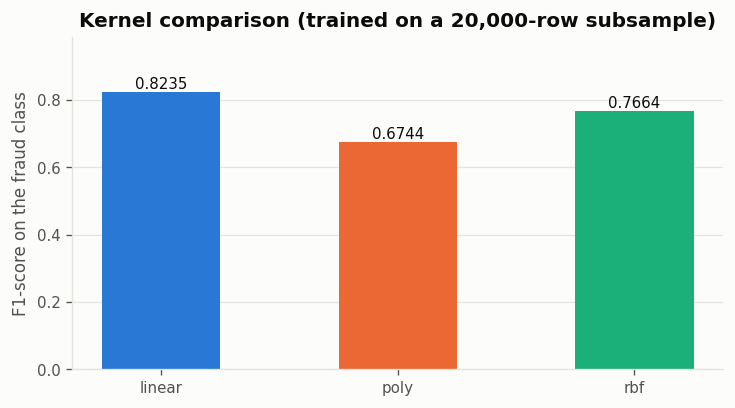

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6))
kr = pd.DataFrame(kernel_rows)
ax.bar(kr["kernel"], kr["f1"], color=[utils.BLUE, utils.ORANGE, utils.GREEN], width=0.5)
for i, v in enumerate(kr["f1"]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=9, color=utils.INK)
ax.set_ylabel("F1-score on the fraud class")
ax.set_title("Kernel comparison (trained on a 20,000-row subsample)")
ax.set_ylim(0, max(kr["f1"])*1.2)
ax.grid(axis="x", visible=False); utils.despine(ax)
utils.save_fig(fig, "06_kernel_comparison.png")
plt.show()

### Choosing C - the soft margin parameter

In [5]:
from sklearn.model_selection import cross_val_score

c_rows = []
for C in [0.1, 1.0, 10.0]:
    m = Pipeline([("scaler", StandardScaler()),
                  ("svm", SVC(kernel="rbf", C=C, gamma="scale",
                              random_state=SEED))])
    s = cross_val_score(m, X_small, y_small, cv=3, scoring="average_precision", n_jobs=1)
    c_rows.append({"C": C, "cv_pr_auc": s.mean(), "std": s.std()})
    print(f"  C={C:<5} : PR-AUC = {s.mean():.4f}  (+/- {s.std():.4f})")

cdf = pd.DataFrame(c_rows)
best_C = float(cdf.loc[cdf["cv_pr_auc"].idxmax(), "C"])
print(f"\nBest C by cross validation: {best_C}")

  C=0.1   : PR-AUC = 0.8707  (+/- 0.0322)


  C=1.0   : PR-AUC = 0.8826  (+/- 0.0276)


  C=10.0  : PR-AUC = 0.8952  (+/- 0.0186)

Best C by cross validation: 10.0


saved figure -> Results/figures/06_C_selection.png


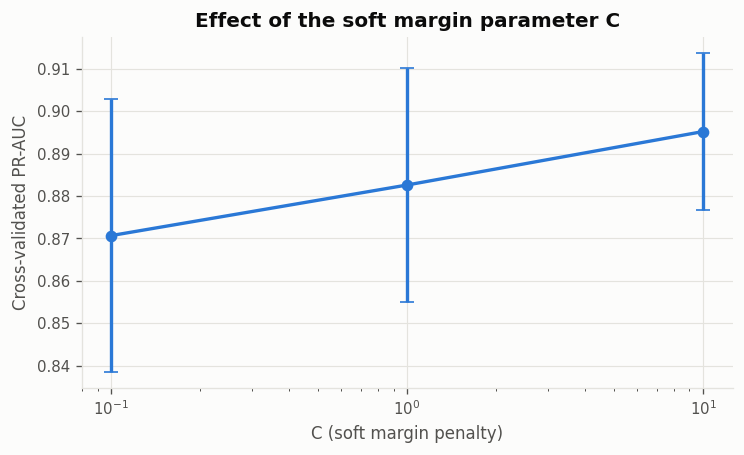

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(cdf["C"], cdf["cv_pr_auc"], yerr=cdf["std"], marker="o",
            color=utils.BLUE, capsize=4)
ax.set_xscale("log")
ax.set_xlabel("C (soft margin penalty)"); ax.set_ylabel("Cross-validated PR-AUC")
ax.set_title("Effect of the soft margin parameter C")
utils.despine(ax)
utils.save_fig(fig, "06_C_selection.png")
plt.show()

## 6. The final model

> **A note on `class_weight`.** Re-weighting the fraud class by the inverse of
> its frequency (roughly 600:1) was tried for this model and rejected, for the
> same reason set out in Notebook 03: on a single (non-ensemble) model it tips a
> very large number of borderline decisions to "fraud", trading a little recall
> for an unusable number of false alarms. The imbalance is handled instead
> through the choice of evaluation metric and through the decision-threshold
> analysis of Notebook 05. Random Forest and XGBoost do retain their weighting,
> because averaging over many learners keeps the combined scores well ordered.

In [7]:
t0 = time.time()
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=best_C, gamma="scale",
                probability=True,
                random_state=SEED, cache_size=500)),
])
svm.fit(X_sub, y_sub)
print(f"training time : {time.time()-t0:.1f} seconds on {len(y_sub):,} rows")

sv = svm.named_steps["svm"]
print(f"\nsupport vectors : {sv.n_support_.sum():,} total "
      f"({sv.n_support_[0]:,} legitimate, {sv.n_support_[1]} fraud)")
print(f"that is {sv.n_support_.sum()/len(y_sub)*100:.2f}% of the training subsample")
print("\nOnly these points determine the decision boundary - the dual solution")
print("is sparse, exactly as the KKT conditions predict.")

training time : 14.7 seconds on 40,000 rows

support vectors : 1,240 total (1,013 legitimate, 227 fraud)
that is 3.10% of the training subsample

Only these points determine the decision boundary - the dual solution
is sparse, exactly as the KKT conditions predict.


In [8]:
y_pred  = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)[:, 1]
res = utils.evaluate("Support Vector Machine", y_test, y_pred, y_proba,
                     unit="Unit III - SVM, dual formulation, kernels")
res["kernel"] = "rbf"; res["C"] = best_C
res["n_support_vectors"] = int(sv.n_support_.sum())
res["note"] = f"trained on a {len(y_sub):,}-row stratified subsample (all frauds kept)"
utils.save_result(res, y_proba)


===== Support Vector Machine =====
syllabus  : Unit III - SVM, dual formulation, kernels
accuracy  : 0.99932
precision : 0.8333
recall    : 0.7394
f1-score  : 0.7836
PR-AUC    : 0.7841
ROC-AUC   : 0.9696
confusion : TN=84,955  FP=21  FN=37  TP=105

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     84976
       Fraud     0.8333    0.7394    0.7836       142

    accuracy                         0.9993     85118
   macro avg     0.9164    0.8696    0.8916     85118
weighted avg     0.9993    0.9993    0.9993     85118

saved result -> Results/tables/support_vector_machine.json


saved figure -> Results/figures/06_confusion.png


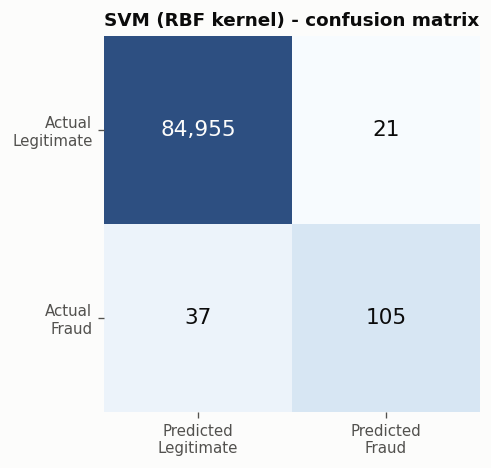

saved figure -> Results/figures/06_pr_curve.png


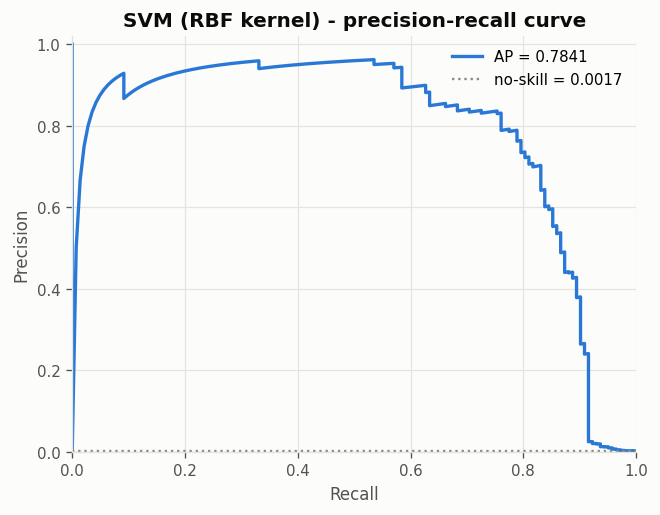

saved figure -> Results/figures/06_roc_curve.png


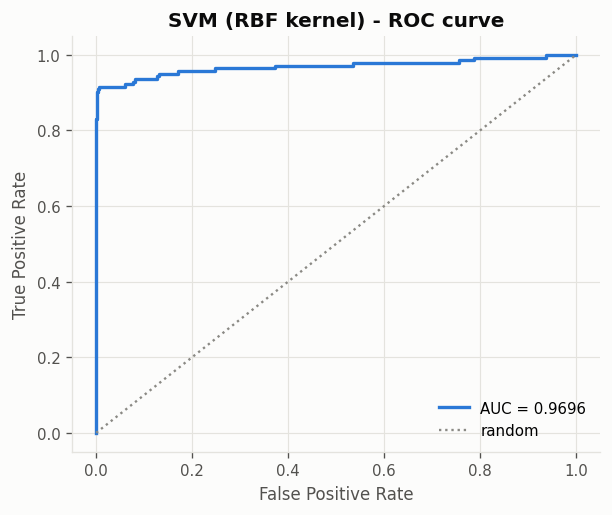

In [9]:
utils.plot_confusion(y_test, y_pred, "SVM (RBF kernel) - confusion matrix",
                     "06_confusion.png"); plt.show()
utils.plot_pr_curve(y_test, y_proba, "SVM (RBF kernel) - precision-recall curve",
                    "06_pr_curve.png"); plt.show()
utils.plot_roc_curve(y_test, y_proba, "SVM (RBF kernel) - ROC curve",
                     "06_roc_curve.png"); plt.show()

## 7. Visualising the margin and the support vectors

The fraud data lives in 30 dimensions and cannot be drawn. To make the concepts
of Sections 1-4 visible, a linear and an RBF SVM are fitted to a two-dimensional
projection of our own data (the two attributes with the strongest information
gain), and the decision boundary, the margin and the support vectors are plotted.

saved figure -> Results/figures/06_margin_and_support_vectors.png


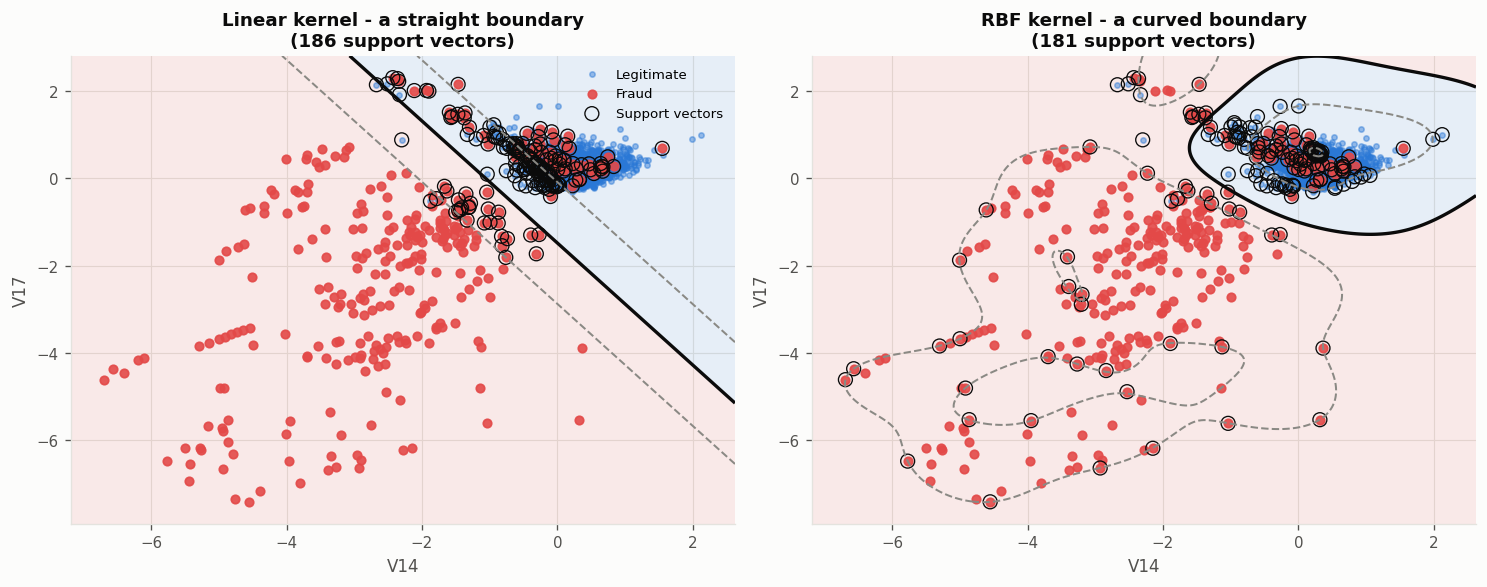

In [10]:
cols2 = ["V14", "V17"]
Xa, ya = utils.subsample_train(X_train[cols2], y_train, 3000)
sc = StandardScaler().fit(Xa)
Xa_s = sc.transform(Xa)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, kern, title in zip(axes, ["linear", "rbf"],
                           ["Linear kernel - a straight boundary",
                            "RBF kernel - a curved boundary"]):
    m = SVC(kernel=kern, C=1.0, gamma="scale",
            random_state=SEED).fit(Xa_s, ya)

    x_min, x_max = Xa_s[:, 0].min()-0.5, Xa_s[:, 0].max()+0.5
    y_min, y_max = Xa_s[:, 1].min()-0.5, Xa_s[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                         np.linspace(y_min, y_max, 250))
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], colors=[utils.BLUE, utils.RED],
                alpha=0.10)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=[utils.MUTED, utils.INK, utils.MUTED],
               linestyles=["--", "-", "--"], linewidths=[1.2, 2, 1.2])

    leg = ya == 0
    ax.scatter(Xa_s[leg, 0], Xa_s[leg, 1], s=10, color=utils.BLUE, alpha=0.45,
               label="Legitimate")
    ax.scatter(Xa_s[~leg, 0], Xa_s[~leg, 1], s=26, color=utils.RED, alpha=0.9,
               label="Fraud")
    ax.scatter(Xa_s[m.support_, 0], Xa_s[m.support_, 1], s=70, facecolors="none",
               edgecolors=utils.INK, linewidths=0.8, label="Support vectors")
    ax.set_xlabel(cols2[0]); ax.set_ylabel(cols2[1])
    ax.set_title(f"{title}\n({m.n_support_.sum()} support vectors)", fontsize=11)
    utils.despine(ax)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
utils.save_fig(fig, "06_margin_and_support_vectors.png")
plt.show()

The solid line is the decision boundary, the dashed lines mark the margin, and
the circled points are the support vectors lying on or inside it. The linear
kernel can only produce a straight boundary; the RBF kernel curves around the
fraud cluster. Note also that the support vectors are a small fraction of the
data - everything else could be removed without changing the boundary at all.

## 8. Summary

- The SVM finds the maximum-margin separating hyperplane; only the **support
  vectors** determine it.
- The **dual formulation** expresses the problem purely in terms of inner
  products between training points, which is what makes kernels possible.
- The **soft margin** parameter C trades margin width against training errors and
  is what allows the SVM to cope with noisy, overlapping data.
- The **kernel trick** gives a nonlinear boundary without ever computing the
  high-dimensional mapping. The RBF kernel outperformed linear and polynomial on
  this data.
- The practical cost is severe: SVM training scales worse than quadratically in
  the number of examples, which forced a training subsample and made this the
  slowest model in the project.